# Understand the MovieLens dataset

**Goal:** Check whether the data is ready for our movie-preference project and learn its main patterns.

We will **open the files → check for problems → make charts → write down what we learned**. We are not training a model yet.

### How to use this notebook
- Keep the notebook in the same folder as `ml-20m`.
- Use a Python environment with pandas, NumPy, Matplotlib, and Jupyter.
- Run the cells from top to bottom with **Shift + Enter**, or choose **Run All**.
- The notebook reads all 20 million ratings, so allow several minutes and a few GB of free memory.
- Your original CSV files stay unchanged. Results go into `outputs/exploration`.

## 1. Get ready
**What we do:** Load the Python tools, find the dataset folder, and choose where to save results.

**What to look for:** The printed dataset path should end in `ml-20m`. If the folder is missing, fix its location before continuing.

In [1]:
# Load the tools used below.
from pathlib import Path

import platform

import sqlite3

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Find the input folder and create the results folder.
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "ml-20m").is_dir() and (PROJECT_DIR / "Project/ml-20m").is_dir():
    PROJECT_DIR = PROJECT_DIR / "Project"
DATA_DIR = PROJECT_DIR / "ml-20m"
OUT_DIR = PROJECT_DIR / "outputs/exploration"

OUT_DIR.mkdir(parents=True, exist_ok=True)
CHUNK_SIZE = 500_000

assert DATA_DIR.is_dir(), f"Dataset folder not found: {DATA_DIR}"

# Make tables and charts easier to read.
pd.set_option("display.max_columns", 12)
plt.style.use("default")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
# Show the software versions and folders used for this run.
print(f"Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}")
print(f"Dataset: {DATA_DIR}\nOutputs: {OUT_DIR}")

# Helper: save a table as a CSV file.
def save_table(frame, name):
    """Save an analysis table without adding a meaningless row-index column."""
    frame.to_csv(OUT_DIR / f"{name}.csv", index=False)
    return frame

# Helper: save and display a chart, then close it.
def finish_chart(name):
    """Save the current figure and also display it in the notebook."""

    plt.tight_layout()

    plt.savefig(OUT_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.close()

Matplotlib is building the font cache; this may take a moment.


Python 3.14.3 | pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.8
Dataset: /Users/pyaesonethantkyaw/Mahidol/data mining/Project/ml-20m
Outputs: /Users/pyaesonethantkyaw/Mahidol/data mining/Project/outputs/exploration


## 2. What is inside each file?
**What we do:** Show a few example rows and check that all six files have the expected columns.

| File | What it contains |
|---|---|
| `ratings.csv` | Who rated which movie, their score, and when |
| `movies.csv` | Movie titles and genres |
| `tags.csv` | Words or phrases users added to movies |
| `links.csv` | Movie IDs for other websites |
| `genome-tags.csv` | Names of the predefined movie characteristics |
| `genome-scores.csv` | How strongly each movie matches those characteristics |

For example, `userId=123, movieId=1, rating=4.5` means user 123 gave movie 1 a score of 4.5 stars. IDs let us connect information between files.

**What to look for:** Each preview should match the description above. These previews are examples; later checks use the full files.

In [2]:
# List the columns that each file should contain.
expected = {
    "ratings.csv": ["userId", "movieId", "rating", "timestamp"],
    "movies.csv": ["movieId", "title", "genres"],
    "tags.csv": ["userId", "movieId", "tag", "timestamp"],
    "links.csv": ["movieId", "imdbId", "tmdbId"],
    "genome-tags.csv": ["tagId", "tag"],
    "genome-scores.csv": ["movieId", "tagId", "relevance"],
}

inventory = []
# Check each file and show a small preview.
for filename, columns in expected.items():
    path = DATA_DIR / filename
    assert path.is_file(), f"Missing source file: {filename}"

    # Only read five rows for this preview.
    sample = pd.read_csv(path, nrows=5)

    assert list(sample.columns) == columns, f"Unexpected schema: {filename}"

    # Save the file name, size, and columns for our report.
    inventory.append({"file": filename, "size_MiB": path.stat().st_size / 1024**2,
                      "columns": ", ".join(columns)})
    print(filename)

    display(sample.head(3))

# Show and save the file summary.
display(save_table(pd.DataFrame(inventory), "file_inventory"))

ratings.csv


,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819


movies.csv


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


tags.csv


...

genome-tags.csv


,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century


genome-scores.csv


,movieId,tagId,relevance
0,1,1,0.02500
1,1,2,0.02500
2,1,3,0.05775


,file,size_MiB,columns
0,ratings.csv,508.732234,"userId, movieId, rating, timestamp"
1,movies.csv,1.332800,"movieId, title, genres"
2,tags.csv,15.834805,"userId, movieId, tag, timestamp"
3,links.csv,0.543680,"movieId, imdbId, tmdbId"
4,genome-tags.csv,0.017264,"tagId, tag"
5,genome-scores.csv,308.555966,"movieId, tagId, relevance"


## 3. Read the data
**What we do:** Load the ratings and the smaller files into tables called DataFrames.

The genome-score file is large, so we will read it in smaller batches in step 5. The numeric types in the code help reduce memory use.

**What to look for:** The output lists the column types and memory used by the ratings table. `int` means whole numbers, `float` means decimal numbers, and `string` or `object` usually holds text here.

In [3]:
# Read the full ratings file using smaller numeric types to save memory.
ratings = pd.read_csv(DATA_DIR / "ratings.csv", dtype={
    "userId": "int32", "movieId": "int32", "rating": "float32", "timestamp": "int64"})

# Read the smaller files.
movies = pd.read_csv(DATA_DIR / "movies.csv", dtype={"movieId": "int32"})

tags = pd.read_csv(DATA_DIR / "tags.csv", dtype={"userId": "int32", "movieId": "int32", "timestamp": "int64"})

# Website IDs are labels, so keep them as text.
links = pd.read_csv(DATA_DIR / "links.csv", dtype={"movieId": "int32", "imdbId": "string", "tmdbId": "string"})

genome_tags = pd.read_csv(DATA_DIR / "genome-tags.csv", dtype={"tagId": "int32"})

# Put the tables together so we can check them in a loop.
tables = {"ratings": ratings, "movies": movies, "tags": tags,
          "links": links, "genome-tags": genome_tags}

# Show memory use and column types.
print(f"Ratings table memory: {ratings.memory_usage(deep=True).sum() / 1024**2:,.1f} MiB")

display(pd.DataFrame([{"table": name, "column": col, "dtype": str(dtype)}
                      for name, df in tables.items() for col, dtype in df.dtypes.items()]))

Ratings table memory: 381.5 MiB


,table,column,dtype
0,ratings,userId,int32
1,ratings,movieId,int32
2,ratings,rating,float32
3,ratings,timestamp,int64
4,movies,movieId,int32
5,movies,title,str
6,movies,genres,str
7,tags,userId,int32
8,tags,movieId,int32
9,tags,tag,str


## 4. Are there missing or repeated values?
**What we do:** Check for empty values, repeated records, ratings outside the allowed values, and missing movie details.

**How to read the result:** `count = 0` means that check found no problem. A positive count tells us how many values or extra rows need attention.

- Ratings must be 0.5, 1.0, 1.5, …, 5.0.
- We check whether the same user rated the same movie more than once.
- `(no genres listed)` also means genre information is missing.
- Two movies can share a title, so matching titles need review before deletion.
- A timestamp is a date stored as seconds. We convert it into a readable date.

We only report these findings here. We do not remove records.

In [4]:
# Collect all check results in one list.
quality = []
# Check each table for missing values and repeated rows.
for name, df in tables.items():

    for column in df.columns:
        quality.append({"table": name, "check": f"missing {column}", "count": int(df[column].isna().sum())})

    quality.append({"table": name, "check": "exact duplicate rows beyond first", "count": int(df.duplicated().sum())})

# Helper: add one result to the list.
def record(table, check, count):
    quality.append({"table": table, "check": check, "count": int(count)})

# Check repeated user/movie pairs and scores outside the allowed values.
record("ratings", "repeated userId/movieId beyond first", ratings.duplicated(["userId", "movieId"]).sum())

record("ratings", "invalid rating (expected 0.5 to 5.0 in half steps)", (~ratings.rating.isin(np.arange(0.5, 5.1, 0.5))).sum())

# Check that each movie or tag ID appears only once in its lookup table.
for name, df, key in [("movies", movies, "movieId"), ("links", links, "movieId"), ("genome-tags", genome_tags, "tagId")]:
    record(name, f"duplicate {key} beyond first", df.duplicated(key).sum())

# Check missing movie details and empty tag text.
record("movies", "no genres listed", movies.genres.eq("(no genres listed)").sum())

record("movies", "repeated title beyond first (review only)", movies.duplicated("title").sum())

record("movies", "no trailing four-digit release year", movies.title.str.extract(r"\((\d{4})\)$", expand=False).isna().sum())

record("tags", "blank or missing tag", tags.tag.fillna("").str.strip().eq("").sum())

# Turn seconds into dates. Dates that cannot be read become missing values.
rating_dates = pd.to_datetime(ratings.timestamp, unit="s", utc=True, errors="coerce")
record("ratings", "unparseable timestamp", rating_dates.isna().sum())
record("tags", "unparseable timestamp", pd.to_datetime(tags.timestamp, unit="s", utc=True, errors="coerce").isna().sum())

# Save the results. Zero means this check found no issue.
quality_df = save_table(pd.DataFrame(quality), "quality_audit")
display(quality_df)
print("Rating date range:", rating_dates.min(), "to", rating_dates.max())

,table,check,count
0,ratings,missing userId,0
1,ratings,missing movieId,0
2,ratings,missing rating,0
3,ratings,missing timestamp,0
4,ratings,exact duplicate rows beyond first,0
5,movies,missing movieId,0
6,movies,missing title,0
7,movies,missing genres,0
8,movies,exact duplicate rows beyond first,0
9,tags,missing userId,0


Rating date range: 1995-01-09 11:46:44+00:00 to 2015-03-31 06:40:02+00:00


## 5. Do the files connect correctly?
**What we do:** Check that movie IDs in ratings, tags, and other files exist in `movies.csv`. We also check whether genome scores use valid movie and tag IDs.

The large genome file is checked in batches. A temporary database remembers movie–tag pairs so we can spot repeats even when they occur in different batches. It is deleted when the check finishes.

**How to read the results:**
- In the first table, zero means no issue was found by that check.
- The coverage table shows how much of the dataset has extra tag information. For example, 40% movie coverage means 40 out of every 100 movies have that information.
- Movie coverage and rating coverage are different: a small group of popular movies can contain most ratings.
- The last table gives the full row count of every file.

Missing optional tags do not mean we should delete a valid rating.

In [5]:
# Collect the IDs we expect to find in the related files.
movie_ids = set(movies.movieId)
user_ids = set(ratings.userId.unique())
tag_ids = set(genome_tags.tagId)
relationships = []

# Count records that refer to a movie missing from the movie table.
for name, df in [("ratings", ratings), ("tags", tags), ("links", links)]:
    relationships.append({"check": f"{name}: movieId absent from movies", "count": int((~df.movieId.isin(movie_ids)).sum())})
relationships.append({"check": "tags: userId absent from ratings (review)", "count": int((~tags.userId.isin(user_ids)).sum())})

# Use a temporary file to remember pairs without keeping them all in memory.
import tempfile

with tempfile.TemporaryDirectory(prefix="movielens-audit-") as tmp:
    connection = sqlite3.connect(str(Path(tmp) / "keys.sqlite"))

    # Allow each movie/tag pair to be stored only once.
    connection.execute("CREATE TABLE pairs (movie INTEGER, tag INTEGER, PRIMARY KEY(movie, tag)) WITHOUT ROWID")

    # Start the counters at zero.
    genome_rows = genome_duplicate_pairs = genome_missing = genome_invalid = unknown_movies = unknown_tags = 0
    genome_movie_ids = set()

    # Read and check one batch of genome scores at a time.
    for chunk in pd.read_csv(DATA_DIR / "genome-scores.csv", chunksize=CHUNK_SIZE,
                             dtype={"movieId": "int32", "tagId": "int32", "relevance": "float32"}):

        genome_rows += len(chunk)
        genome_movie_ids.update(chunk.movieId.unique())

        genome_missing += int(chunk.isna().sum().sum())
        genome_invalid += int((~chunk.relevance.between(0, 1)).sum())
        unknown_movies += int((~chunk.movieId.isin(movie_ids)).sum())
        unknown_tags += int((~chunk.tagId.isin(tag_ids)).sum())

        # Count how many pairs were already stored.
        before = connection.total_changes

        # Try to store each pair; repeated pairs are skipped.
        connection.executemany("INSERT OR IGNORE INTO pairs VALUES (?, ?)",
                               ((int(m), int(t)) for m, t in zip(chunk.movieId, chunk.tagId)))

        # Skipped pairs are duplicates. Add them to the running total.
        genome_duplicate_pairs += len(chunk) - (connection.total_changes - before)

    connection.commit()

    # Check that each covered movie has a score for every predefined tag.
    incomplete_genome_movies = connection.execute(
        "SELECT COUNT(*) FROM (SELECT movie FROM pairs GROUP BY movie HAVING COUNT(*) != ?)",
        (len(genome_tags),)).fetchone()[0]
    connection.close()

# Add the genome results to the other checks.
relationships.extend([
    {"check": "genome: movieId absent from movies", "count": unknown_movies},
    {"check": "genome: tagId absent from genome-tags", "count": unknown_tags},
    {"check": "genome: missing cells", "count": genome_missing},
    {"check": "genome: invalid relevance", "count": genome_invalid},
    {"check": "genome: duplicate movie/tag pairs beyond first", "count": genome_duplicate_pairs},
    {"check": "genome: movies without full tag vocabulary", "count": incomplete_genome_movies},
])
display(save_table(pd.DataFrame(relationships), "relationship_audit"))

# Measure how many users, movies, and ratings have extra tag information.
coverage = pd.DataFrame([
    {"measure": "Users supplying tags / rating users", "covered": tags.loc[tags.userId.isin(user_ids), "userId"].nunique(), "total": len(user_ids)},
    {"measure": "Movies with ratings / catalog movies", "covered": ratings.movieId.nunique(), "total": len(movies)},
    {"measure": "Movies with user tags / catalog movies", "covered": tags.loc[tags.movieId.isin(movie_ids), "movieId"].nunique(), "total": len(movies)},
    {"measure": "Movies with genome / catalog movies", "covered": len(genome_movie_ids & movie_ids), "total": len(movies)},
    {"measure": "Rating rows with genome / all ratings", "covered": int(ratings.movieId.isin(genome_movie_ids).sum()), "total": len(ratings)},
])

# Convert each fraction to a percentage.
coverage["percent"] = 100 * coverage.covered / coverage.total
display(save_table(coverage, "enrichment_coverage"))

# Save the full number of rows in each file.
counts = pd.DataFrame([{"file": name + ".csv", "rows": len(df)} for name, df in tables.items()] +
                      [{"file": "genome-scores.csv", "rows": genome_rows}])
display(save_table(counts, "row_counts"))

,check,count
0,ratings: movieId absent from movies,0
1,tags: movieId absent from movies,0
2,links: movieId absent from movies,0
3,tags: userId absent from ratings (review),0
4,genome: movieId absent from movies,0
5,genome: tagId absent from genome-tags,0
6,genome: missing cells,0
7,genome: invalid relevance,0
8,genome: duplicate movie/tag pairs beyond first,0
9,genome: movies without full tag vocabulary,0


,measure,covered,total,percent
0,Users supplying tags / rating users,7801,138493,5.632776
1,Movies with ratings / catalog movies,26744,27278,98.042378
2,Movies with user tags / catalog movies,19545,27278,71.651147
3,Movies with genome / catalog movies,10381,27278,38.056309
4,Rating rows with genome / all ratings,19800443,20000263,99.000913


,file,rows
0,ratings.csv,20000263
1,movies.csv,27278
2,tags.csv,465564
3,links.csv,27278
4,genome-tags.csv,1128
5,genome-scores.csv,11709768


## 6. What scores do users give, and when?
**What we do:** Make two charts.

1. **Rating distribution:** Count how often each score was given. A taller bar means more ratings at that score.
2. **Ratings by year:** Count rating submissions in each year. A taller bar means more rating activity.

**What to look for:** Which score is most common? Which years have the most ratings?

The data ends in March 2015, so 2015 is not a full year. These are ratings submitted, not movies watched.

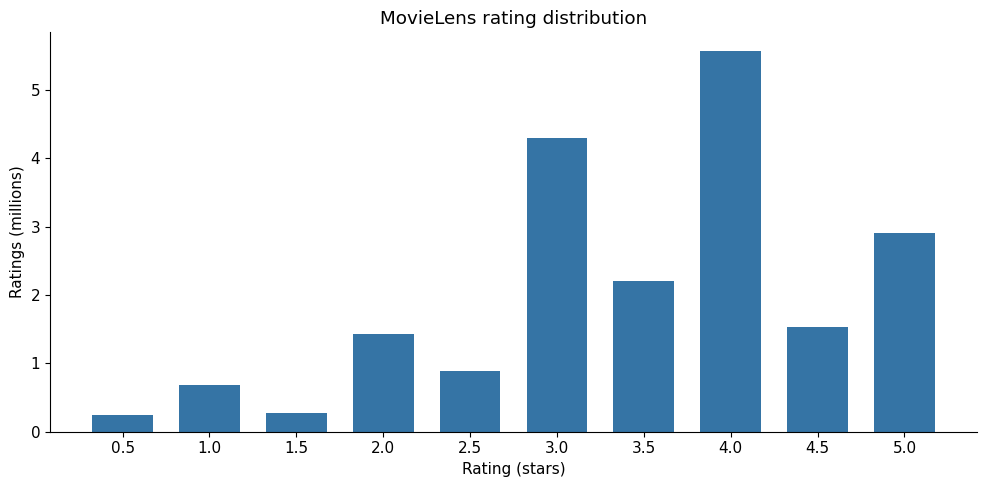

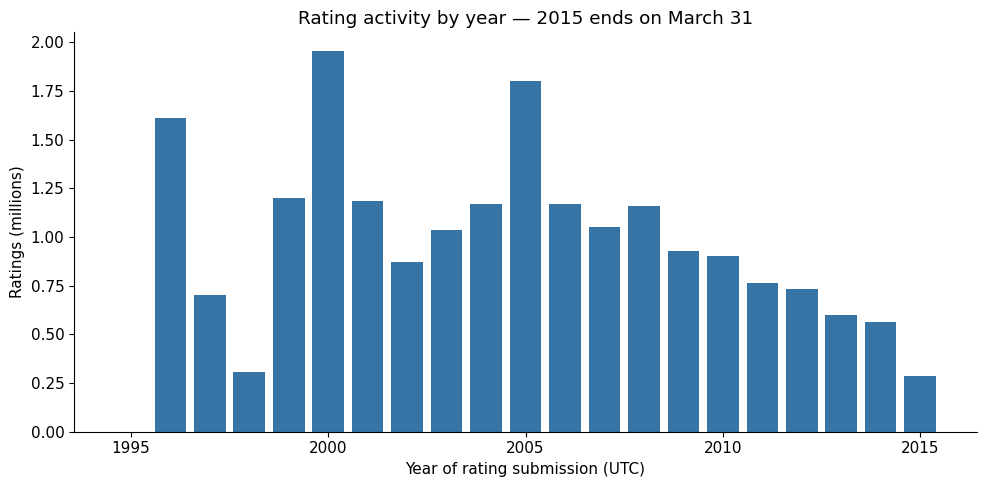

,rating
count,2.000026e+07
mean,3.525529e+00
std,1.051989e+00
min,5.000000e-01
25%,3.000000e+00
50%,3.500000e+00
75%,4.000000e+00
max,5.000000e+00


In [6]:
# Count how many times each star score appears.
rating_distribution = ratings.groupby("rating").size().rename("rating_count").reset_index()
save_table(rating_distribution, "rating_distribution")

# Draw the score chart, with counts shown in millions.
plt.bar(rating_distribution.rating, rating_distribution.rating_count / 1e6, width=0.35, color="#3574A5")
plt.xticks(np.arange(0.5, 5.1, 0.5)); plt.xlabel("Rating (stars)"); plt.ylabel("Ratings (millions)")
plt.title("MovieLens rating distribution")
finish_chart("rating_distribution")

# Group ratings by year and count them.
annual = ratings.groupby(rating_dates.dt.year).agg(rating_count=("rating", "size"), mean_rating=("rating", "mean"))

annual.index.name = "year"
annual = annual.reset_index()
save_table(annual, "annual_rating_activity")
# Draw yearly activity and show that the final year is incomplete.
plt.bar(annual.year, annual.rating_count / 1e6, color="#3574A5")
plt.xlabel("Year of rating submission (UTC)"); plt.ylabel("Ratings (millions)")

plt.title(f"Rating activity by year — {int(annual.year.max())} ends on {rating_dates.max():%B %d}")
finish_chart("annual_rating_activity")

# Show basic statistics such as the average and middle rating.
display(ratings.rating.describe().to_frame("rating"))

## 7. Which movies and genres appear most often?
**What we do:** Show the 15 movies with the most ratings, then count movies in each genre.

**What to look for:** The top movie chart measures rating activity, not movie quality. The genre chart describes which genres are common in the catalog.

A movie such as an action-comedy belongs to both genres. It is counted once in each, so adding the genre bars will not give the number of unique movies.

The genre table also includes average ratings. We calculate this as **total rating points ÷ number of ratings**, so each rating has equal weight.

,movieId,title,rating_count,mean_rating
293,296,Pulp Fiction (1994),67310,4.174231
352,356,Forrest Gump (1994),66172,4.029000
315,318,"Shawshank Redemption, The (1994)",63366,4.446990
587,593,"Silence of the Lambs, The (1991)",63299,4.177056
476,480,Jurassic Park (1993),59715,3.664741
257,260,Star Wars: Episode IV - A New Hope (1977),54502,4.190672
108,110,Braveheart (1995),53769,4.042534
583,589,Terminator 2: Judgment Day (1991),52244,3.931954
2486,2571,"Matrix, The (1999)",51334,4.187186
523,527,Schindler's List (1993),50054,4.310175


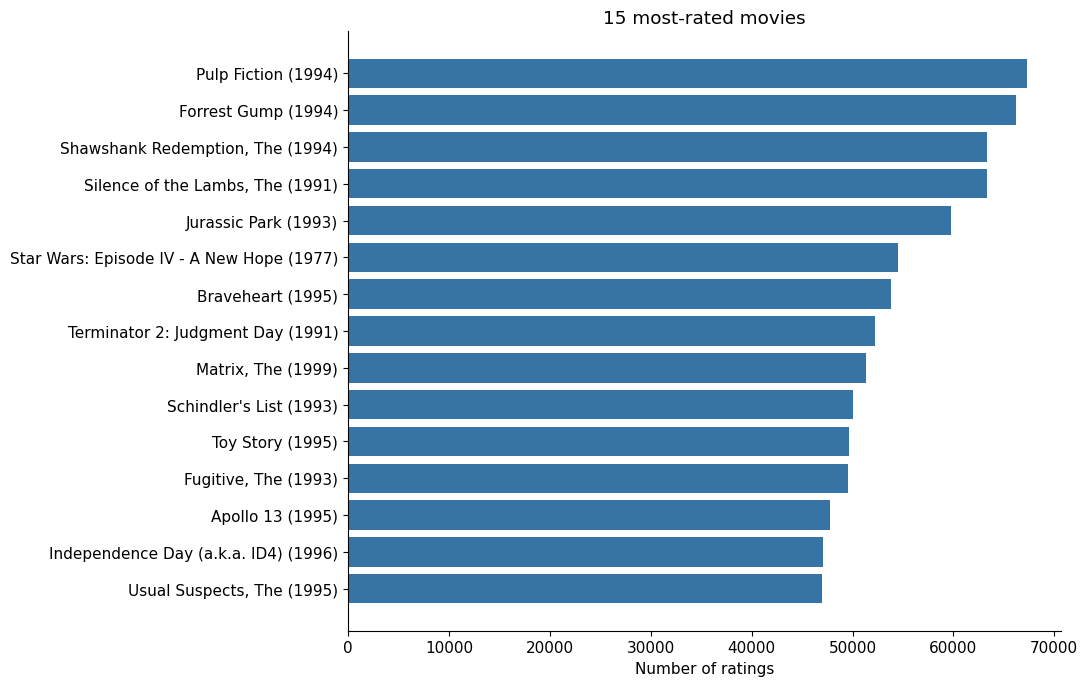

,genre,catalog_movies,rating_count,rating_sum,mean_rating
8,Drama,13344,8857853.0,32546370.0,3.674296
5,Comedy,8374,7502234.0,25702738.0,3.426011
17,Thriller,4178,5313506.0,18635056.0,3.507111
15,Romance,4127,3802002.0,13465940.0,3.541802
1,Action,3520,5614208.0,19334568.0,3.443864
6,Crime,2939,3298335.0,12119823.0,3.674528
11,Horror,2611,1482737.0,4859261.0,3.277224
7,Documentary,2471,244619.0,914806.0,3.739718
2,Adventure,2329,4380351.0,15339519.0,3.501893
16,Sci-Fi,1743,3150141.0,10826318.0,3.436773


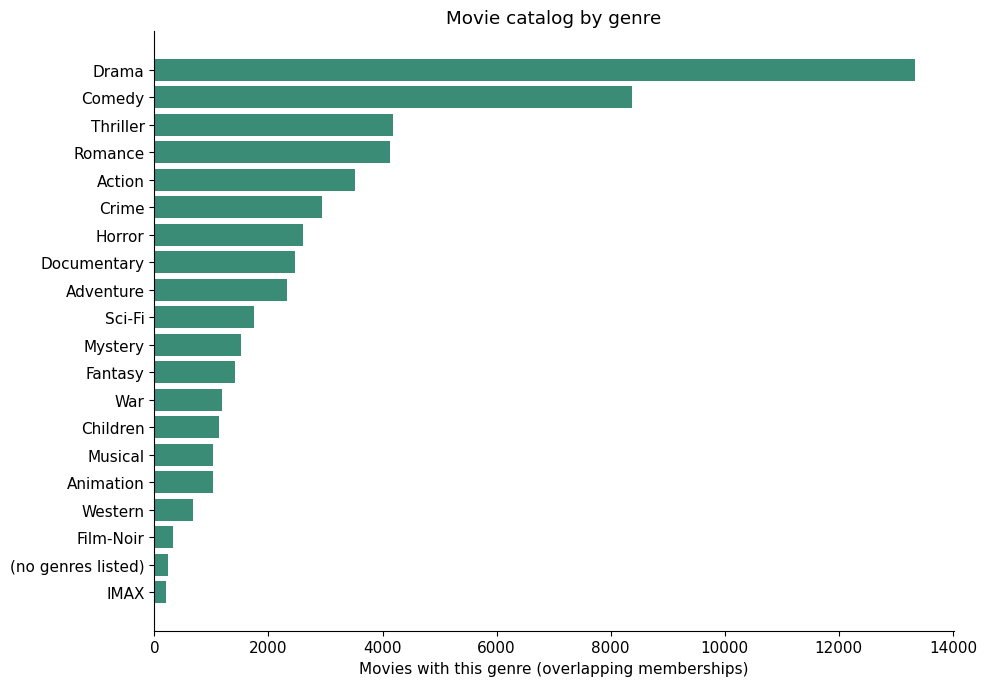

In [7]:
# Calculate the count, total points, and average rating for each movie.
movie_stats = ratings.groupby("movieId").agg(rating_count=("rating", "size"), rating_sum=("rating", "sum"), mean_rating=("rating", "mean")).reset_index()

# Match each movie ID with its title and genres.
movie_stats = movie_stats.merge(movies, on="movieId", how="left", validate="one_to_one")

# Pick the 15 movies with the most ratings.
top_movies = movie_stats.nlargest(15, "rating_count")[["movieId", "title", "rating_count", "mean_rating"]]
display(save_table(top_movies, "most_rated_movies"))
# Draw the movie chart.
plt.figure(figsize=(11, 7))

plt.barh(top_movies.title.iloc[::-1], top_movies.rating_count.iloc[::-1], color="#3574A5")
plt.xlabel("Number of ratings"); plt.title("15 most-rated movies")
finish_chart("most_rated_movies")

# Split genre lists so each row contains one movie and one genre.
movie_genres = movies[["movieId", "genres"]].assign(genre=movies.genres.str.split("|")).explode("genre").drop(columns="genres")

# Remove any repeated movie/genre combinations.
movie_genres = movie_genres.drop_duplicates(["movieId", "genre"])

# Attach each movie's rating totals to its genres.
genre_stats = movie_genres.merge(movie_stats[["movieId", "rating_count", "rating_sum"]], on="movieId", how="left", validate="many_to_one")

# Combine movie counts and rating totals for each genre.
genre_stats = genre_stats.groupby("genre").agg(catalog_movies=("movieId", "size"), rating_count=("rating_count", "sum"), rating_sum=("rating_sum", "sum")).reset_index()

# Average rating = total points divided by total ratings.
genre_stats["mean_rating"] = genre_stats.rating_sum / genre_stats.rating_count.replace(0, np.nan)

# Show the most common genres first.
genre_stats = genre_stats.sort_values("catalog_movies", ascending=False)
display(save_table(genre_stats, "genre_summary"))
plt.figure(figsize=(10, 7))

plt.barh(genre_stats.genre.iloc[::-1], genre_stats.catalog_movies.iloc[::-1], color="#3B8C77")
plt.xlabel("Movies with this genre (overlapping memberships)"); plt.title("Movie catalog by genre")
finish_chart("genre_frequency")

## 8. How do users differ?
**What we do:** Calculate three values for each user:
- **rating_count:** How many ratings they gave.
- **mean_rating:** Their average score.
- **rating_std:** How much their scores vary. A larger value means more variation.

**What to look for:** The chart shows whether most users rate a few movies or many. Its horizontal axis uses a log scale so small and large counts can fit in one chart; equal gaps represent multiplication rather than addition.

In the table, `50%` is the middle value. `95%` means 95% of users are at or below that value.

These results can help us plan user grouping later. For prediction, we must recalculate features using training data only.

,rating_count,mean_rating,rating_std
count,138493.000000,138493.000000,138493.000000
mean,144.413530,3.627209,0.952647
std,230.267257,0.443030,0.238260
min,20.000000,0.500000,0.000000
25%,35.000000,3.369478,0.786956
50%,68.000000,3.653846,0.930162
75%,155.000000,3.923077,1.095445
95%,520.000000,4.290323,1.374722
99%,1113.080000,4.541945,1.606441
max,9254.000000,5.000000,2.308451


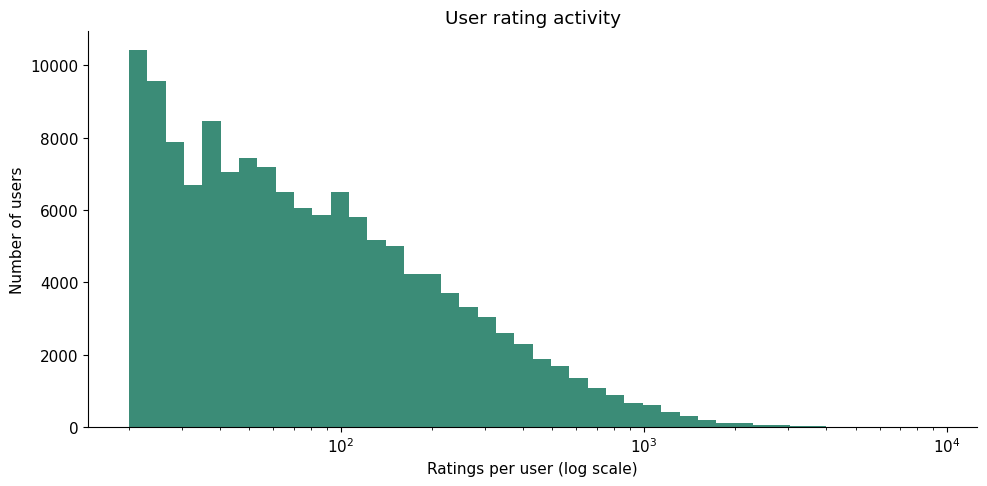

In [8]:
# Calculate how many ratings each user gave, their average, and score variation.
user_stats = ratings.groupby("userId").agg(rating_count=("rating", "size"), mean_rating=("rating", "mean"), rating_std=("rating", "std"))

# Show typical values and values near the upper end.
display(user_stats.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

# Save these summary statistics for the report.
save_table(user_stats.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).rename_axis("statistic").reset_index(), "user_activity_summary")

# Draw how many users fall into each rating-count range.
plt.hist(user_stats.rating_count, bins=np.geomspace(user_stats.rating_count.min(), user_stats.rating_count.max() + 1, 45), color="#3B8C77")

# Use a log scale to fit both small and large rating counts.
plt.xscale("log"); plt.xlabel("Ratings per user (log scale)"); plt.ylabel("Number of users")
plt.title("User rating activity")
finish_chart("user_activity")

## 9. Save what we learned
**What we do:** Create a short findings report from the results above and list the saved files.

**What to look for:** Read the report to identify missing information and decisions for the next stage. Keep the CSV tables and five charts as evidence for your project report.

**Next step:** Design the warehouse tables and decide how to handle the issues found. This notebook does not yet build the warehouse or prove model accuracy.

Source: [MovieLens 20M, GroupLens](https://grouplens.org/datasets/movielens/20m/). More field definitions and usage conditions are in `ml-20m/README.txt`.

In [9]:
# Pick checks that found something needing attention.
nonzero = quality_df.loc[quality_df["count"] > 0]

# Turn those results into readable bullet points.
issue_text = "\n".join(f"- {r.table}: {r.check}: {r.count:,}" for r in nonzero.itertuples()) or "- No issues detected by the listed checks."

# Build the report using the numbers calculated above.
summary = f"""# MovieLens exploration findings

## Verified scope
- Ratings: {len(ratings):,}; rating users: {len(user_ids):,}; catalog movies: {len(movies):,}.
- Tag applications: {len(tags):,}; genome scores: {genome_rows:,}.
- Rating dates: {rating_dates.min():%Y-%m-%d} to {rating_dates.max():%Y-%m-%d} UTC.
- Genome movie coverage: {len(genome_movie_ids & movie_ids) / len(movies):.1%}.
- Mean rating: {ratings.rating.mean():.3f} stars.

## Nonzero quality findings (overlapping checks are not additive)
{issue_text}

## Decisions for warehouse design
- Preserve raw files; record transformations in a separate staging layer.
- Use one rating per user/movie as the intended fact grain, subject to the duplicate audit.
- Add user, movie, and UTC date dimensions and a movie-genre bridge.
- Store tag applications and genome relevance separately to prevent join multiplication.
- Retain movies without optional tags/genome data; add explicit coverage indicators.
- Missing external IDs need not remove otherwise valid rating records.
- Treat missing release years as unknown; review duplicate titles before any deduplication.

## Decisions for mining
- Start clustering with activity, rating behavior, and genre preferences; interpret groups after fitting.
- Split prediction data before feature engineering; use only earlier history for future predictions.
- Compute baselines and learned preprocessing from training data only.
- Evaluate rating regression with MAE/RMSE against global and movie mean baselines.
- The genome has no per-feature timestamp: report its temporal limitation and compare a model without it.
- No model accuracy, warehouse query speed, or causal effect has been established by this notebook.

## Next deliverable
Define the warehouse schema and ETL rules from the audit, then load and validate the warehouse.
"""

# Save the report and show it below.
(OUT_DIR / "findings.md").write_text(summary, encoding="utf-8")

display(Markdown(summary))
print("Saved outputs:")

# List the files created by this notebook.
for path in sorted(OUT_DIR.iterdir()):
    print(path.name)

# MovieLens exploration findings

## Verified scope
- Ratings: 20,000,263; rating users: 138,493; catalog movies: 27,278.
- Tag applications: 465,564; genome scores: 11,709,768.
- Rating dates: 1995-01-09 to 2015-03-31 UTC.
- Genome movie coverage: 38.1%.
- Mean rating: 3.526 stars.

## Nonzero quality findings (overlapping checks are not additive)
- tags: missing tag: 16
- links: missing tmdbId: 252
- movies: no genres listed: 246
- movies: repeated title beyond first (review only): 16
- movies: no trailing four-digit release year: 229
- tags: blank or missing tag: 23

## Decisions for warehouse design
- Preserve raw files; record transformations in a separate staging layer.
- Use one rating per user/movie as the intended fact grain, subject to the duplicate audit.
- Add user, movie, and UTC date dimensions and a movie-genre bridge.
- Store tag applications and genome relevance separately to prevent join multiplication.
- Retain movies without optional tags/genome data; add explicit coverage indicators.
- Missing external IDs need not remove otherwise valid rating records.
- Treat missing release years as unknown; review duplicate titles before any deduplication.

## Decisions for mining
- Start clustering with activity, rating behavior, and genre preferences; interpret groups after fitting.
- Split prediction data before feature engineering; use only earlier history for future predictions.
- Compute baselines and learned preprocessing from training data only.
- Evaluate rating regression with MAE/RMSE against global and movie mean baselines.
- The genome has no per-feature timestamp: report its temporal limitation and compare a model without it.
- No model accuracy, warehouse query speed, or causal effect has been established by this notebook.

## Next deliverable
Define the warehouse schema and ETL rules from the audit, then load and validate the warehouse.


Saved outputs:
annual_rating_activity.csv
annual_rating_activity.png
enrichment_coverage.csv
file_inventory.csv
findings.md
genre_frequency.png
genre_summary.csv
most_rated_movies.csv
most_rated_movies.png
quality_audit.csv
rating_distribution.csv
rating_distribution.png
relationship_audit.csv
row_counts.csv
user_activity.png
user_activity_summary.csv
